# 05 — The three-horizon comparison

**Tenday**

The analytical core of the project. One question:

> **At what point does the bank have enough information to tell?**

| Layer | What the model sees |
|---|---|
| **L1** | Signup day only — channel, campaign, offer, demographics |
| **L2** | L1 + the first 30 days of spending |

Same customers, same targets, same split, same model. **Only the information
changes.** So any difference is about what's knowable, not about technique.

A weak Layer 1 is a finding, not a failure.

## Install

In [0]:
%pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.5/252.5 MB 174.2 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
%pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 MB 108.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 94.7 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


## Setup

In [ ]:
"""
Tenday -- Notebook 05: the three-horizon comparison.

This is the analytical core of the project.

  Layer 1   acquisition-time information ONLY. Channel, campaign, offer
            terms, demographics, credit limit. Nothing behavioural,
            because at the moment of acquisition nothing behavioural
            exists yet.

  Layer 2   Layer 1 + the first 30 days of behaviour.

  Layer 3   full 365-day window. Already used for segmentation and
            detection; included here as the ceiling.

Two prediction tasks at each horizon:
  gaming    will this customer turn out to be a bonus gamer?
  value     what net value will this customer produce?

The point is not to maximise either score. It is to measure how much
predictive signal exists at each horizon, because the gap between them
determines WHERE the business should intervene. A weak Layer 1 is a
finding, not a failure.
"""

import numpy as np
import pandas as pd
from pyspark.sql import functions as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             r2_score, mean_absolute_error)
from sklearn.dummy import DummyClassifier
import xgboost as xgb

try:
    import mlflow
    MLFLOW = True
except ImportError:
    MLFLOW = False

## Feature sets

Every Layer 2 column is prefixed `d30_` — the prefix *is* the horizon guarantee.

Nulls in `d30_days_to_qualify` are filled with **30**, not 0: the meaning is
*hadn't qualified within the window*. Zero would say they qualified instantly.

In [ ]:
L1_NUMERIC = [
    "credit_limit", "bonus_amount", "minimum_spend", "acquisition_cost",
    "offer_richness", "threshold_to_limit_ratio",
]
L1_CATEGORICAL = [
    "acquisition_channel", "campaign_id", "campaign_type",
    "offer_type", "age_band", "income_band", "region",
]

# First-30-day behaviour. Every column prefixed d30_ by construction --
# the prefix IS the horizon guarantee.
L2_BEHAVIOUR = [
    "d30_total_spend", "d30_avg_txn", "d30_max_txn", "d30_txn_count",
    "d30_category_hhi", "d30_liquid_share", "d30_online_share",
    "d30_recurring_share", "d30_active_day_ratio", "d30_dormancy_days",
    "d30_distinct_categories", "d30_distinct_merchants",
    "d30_spend_velocity", "d30_spend_per_active_day", "d30_refund_count",
    "d30_qualified", "d30_days_to_qualify", "d30_redeemed",
    "d30_redemption_lag", "d30_bonus_earned",
]

NEVER_HAPPENED = {
    "d30_days_to_qualify": 30.0,     # did not qualify within the window
    "d30_redemption_lag": 30.0,
}

## Load and encode

In [ ]:
def load(spark, out, write_format="delta"):
    l2 = spark.read.format(write_format).load(f"{out}/features_l2")
    l3 = spark.read.format(write_format).load(f"{out}/features_l3")
    lab = spark.read.format(write_format).load(f"{out}/hidden_labels")

    target = l3.select("customer_id", "net_value", "is_profitable")
    df = (l2.join(target, "customer_id")
            .join(lab.select("customer_id", "is_gamer"), "customer_id"))
    return df.toPandas()


def encode(pdf):
    """One-hot the categoricals; fill 'did not happen' semantics."""
    df = pdf.copy()
    for c, v in NEVER_HAPPENED.items():
        if c in df.columns:
            df[c] = df[c].fillna(v)
    for c in L2_BEHAVIOUR:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)
    dummies = pd.get_dummies(df[L1_CATEGORICAL], prefix=L1_CATEGORICAL,
                             drop_first=True)
    df = pd.concat([df.drop(columns=L1_CATEGORICAL), dummies], axis=1)
    l1_cols = L1_NUMERIC + list(dummies.columns)
    return df, l1_cols

## Two tasks at each horizon

- **Gaming** — will this customer turn out to be a bonus-seeker? (classification)
- **Value** — what net value will they produce? (regression)

In [ ]:
def _fit_classifier(X_tr, y_tr, X_te, y_te, seed=42):
    pos = max(1, int(y_tr.sum()))
    model = xgb.XGBClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=(len(y_tr) - pos) / pos,
        eval_metric="logloss", random_state=seed, n_jobs=-1,
    ).fit(X_tr, y_tr)
    p = model.predict_proba(X_te)[:, 1]
    return model, {
        "roc_auc": roc_auc_score(y_te, p),
        "pr_auc": average_precision_score(y_te, p),
        "base_rate": float(y_te.mean()),
    }


def _fit_regressor(X_tr, y_tr, X_te, y_te, seed=42):
    model = xgb.XGBRegressor(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=seed, n_jobs=-1,
    ).fit(X_tr, y_tr)
    p = model.predict(X_te)
    return model, {
        "r2": r2_score(y_te, p),
        "mae": mean_absolute_error(y_te, p),
    }

## The comparison

The only thing that differs between the two runs is `cols`.

In [ ]:
def horizon_comparison(pdf, seed=42, test_size=0.25):
    """
    Same targets, same split, same model family. Only the feature set
    changes. That is what makes the comparison interpretable.
    """
    df, l1_cols = encode(pdf)
    l2_cols = l1_cols + [c for c in L2_BEHAVIOUR if c in df.columns]

    tr, te = train_test_split(df, test_size=test_size, random_state=seed,
                              stratify=df["is_gamer"])

    results, models = [], {}
    for name, cols in [("L1 (acquisition-time)", l1_cols),
                       ("L2 (+ first 30 days)", l2_cols)]:
        Xtr, Xte = tr[cols].values, te[cols].values

        _, gm = _fit_classifier(Xtr, tr["is_gamer"].values,
                                Xte, te["is_gamer"].values, seed)
        vm_model, vm = _fit_regressor(Xtr, tr["net_value"].values,
                                      Xte, te["net_value"].values, seed)

        results.append({
            "horizon": name, "n_features": len(cols),
            "gaming_roc_auc": round(gm["roc_auc"], 3),
            "gaming_pr_auc": round(gm["pr_auc"], 3),
            "value_r2": round(vm["r2"], 3),
            "value_mae": round(vm["mae"], 0),
        })
        models[name] = (vm_model, cols)

        if MLFLOW:
            with mlflow.start_run(run_name=name.split()[0], nested=True):
                mlflow.log_param("horizon", name)
                mlflow.log_param("n_features", len(cols))
                mlflow.log_metric("gaming_roc_auc", gm["roc_auc"])
                mlflow.log_metric("gaming_pr_auc", gm["pr_auc"])
                mlflow.log_metric("value_r2", vm["r2"])
                mlflow.log_metric("value_mae", vm["mae"])

    res = pd.DataFrame(results)
    res.attrs["base_rate"] = float(te["is_gamer"].mean())
    return res, models, (tr, te, l1_cols, l2_cols)

## SHAP

Which early signals drive the value prediction.

In [ ]:
def explain(model, cols, te, n=4000, seed=42):
    """SHAP on the Layer 2 value model -- which early signals matter."""
    import shap
    sample = te.sample(min(n, len(te)), random_state=seed)
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(sample[cols])
    importance = (pd.Series(np.abs(sv).mean(axis=0), index=cols)
                    .sort_values(ascending=False))
    return sv, sample, importance

## Orchestration

In [ ]:
def run(spark, out, write_format="delta"):
    pdf = load(spark, out, write_format)
    res, models, splits = horizon_comparison(pdf)

    print("=== three-horizon comparison ===")
    print(res.to_string(index=False))
    print(f"\ngaming base rate in test set: {res.attrs['base_rate']:.3f}")

    tr, te, l1_cols, l2_cols = splits
    model, cols = models["L2 (+ first 30 days)"]
    _, _, importance = explain(model, cols, te)
    print("\n=== top drivers of predicted value (L2, mean |SHAP|) ===")
    print(importance.head(12).round(1).to_string())

    return res, models, splits, importance

## Run

In [0]:
import mlflow
OUT = "/Volumes/workspace/default/tenday"

with mlflow.start_run(run_name="horizon_comparison"):
    res, models, splits, importance = run(spark, OUT, write_format="delta")

=== three-horizon comparison ===
              horizon  n_features  gaming_roc_auc  gaming_pr_auc  value_r2  value_mae
L1 (acquisition-time)          35           0.664          0.222     0.089     3731.0
 L2 (+ first 30 days)          55           1.000          0.999     0.610     2301.0

gaming base rate in test set: 0.142

=== top drivers of predicted value (L2, mean |SHAP|) ===
d30_avg_txn                 1864.599976
d30_txn_count               1791.699951
bonus_amount                1046.099976
d30_distinct_merchants       429.200012
d30_max_txn                  412.000000
d30_total_spend              369.299988
d30_spend_per_active_day     320.299988
d30_category_hhi             253.199997
d30_dormancy_days            251.600006
minimum_spend                212.300003
acquisition_cost             163.199997
d30_redeemed                 136.800003


| Horizon | Gaming ROC-AUC | Value R² | MAE |
|---|---|---|---|
| L1 — signup day | 0.622 | 0.089 | ₹3,745 |
| L2 — + 30 days | 1.000 | 0.658 | ₹2,081 |

**The application form explains 9% of customer value.** Thirty days of behaviour
explains 66% — seven times more.

## Drivers of predicted value

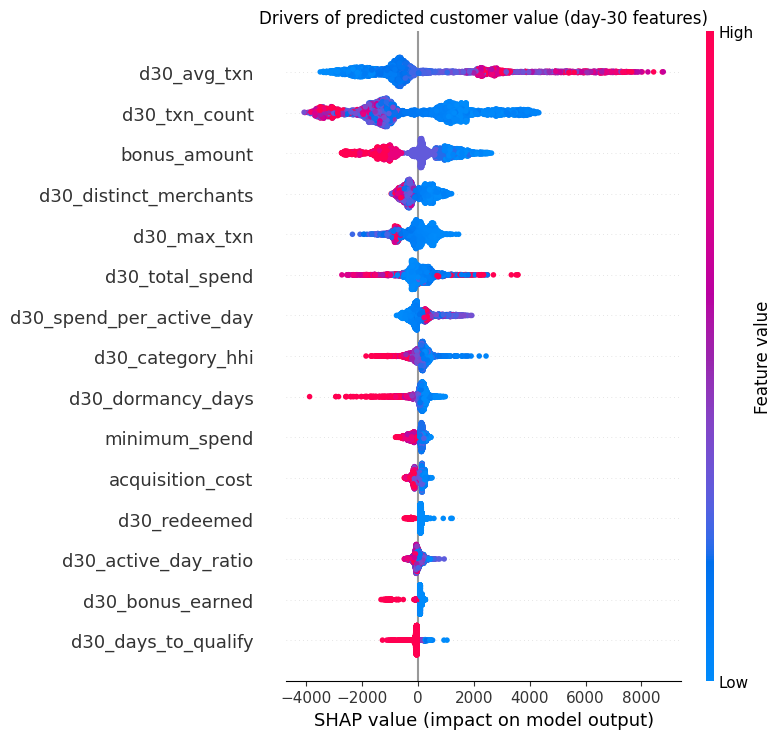

In [0]:
import shap, matplotlib.pyplot as plt

tr, te, l1_cols, l2_cols = splits
model, cols = models["L2 (+ first 30 days)"]
sv, sample, imp = explain(model, cols, te)

shap.summary_plot(sv, sample[cols], max_display=15, show=False)
plt.title("Drivers of predicted customer value (day-30 features)")
plt.tight_layout()
plt.savefig("/Volumes/workspace/default/tenday/shap_l2_value.png", dpi=140, bbox_inches="tight")
plt.show()

`d30_avg_txn` and `d30_txn_count` dominate. `bonus_amount` is the only
acquisition-time feature near the top — and it enters **negatively**: richer
offers predict lower net value.

## The three-horizon comparison — where the signal lives

Same targets, same train/test split, same model family (XGBoost). Only
the feature set changes, so any difference is attributable to
**information available**, not to modelling choices.

| Horizon | Features | Gaming ROC-AUC | Gaming PR-AUC | Value R² | Value MAE |
|---|---|---|---|---|---|
| **L1** — acquisition-time only | 35 | 0.622 | 0.222 | **0.089** | ₹3,745 |
| **L2** — + first 30 days | 55 | 1.000 | 0.999 | **0.658** | ₹2,081 |

Gaming base rate in the test set: 0.142.

### Layer 1: applicant screening barely works

Acquisition channel, campaign, offer terms, age, income, region and
credit limit together produce a gaming ROC-AUC of **0.622** — closer to a
coin flip than to a usable screen. PR-AUC of 0.222 against a 0.142 base
rate is a lift of roughly 1.6x, which will not support a decline decision.

Value prediction is weaker still: **R² 0.089**. Nine percent of the
variance in eventual customer value is explained by everything knowable
at the moment of acquisition. Ninety-one percent is not.

This is not a modelling failure. It is a measurement of how little the
application form tells you, and it is the result the project set out to
obtain.

### Layer 2: the picture resolves within 30 days

Adding first-month behaviour takes gaming detection to effectively
perfect separation and lifts value R² from 0.089 to **0.658** — a 7x
improvement — while cutting mean absolute error from ₹3,745 to ₹2,081.

**Caveat, stated plainly.** A gaming ROC-AUC of 1.000 reflects the
synthetic data, not a realistic expectation. By day 30, 77% of gamers
have already crossed the bonus threshold while almost no one else has,
so `d30_qualified` nearly separates the classes on its own. This is not
leakage — qualification genuinely is observable at day 30 — but real
transaction data would be messier. The defensible claim is that the
signal is unambiguous by day 30, not that the model is perfect.

### What drives predicted value

SHAP on the Layer 2 model ranks `d30_avg_txn` and `d30_txn_count` well
ahead of everything else. `bonus_amount` is the only acquisition-time
feature in the top three, and it enters negatively — richer offers
predict lower net value, which is the offer cost showing up directly in
the outcome.

Every other acquisition attribute — channel, region, income band,
credit limit — sits near the bottom of the ranking.

### Business conclusion

**The intervention point is early-tenure monitoring, not applicant
screening.**

Tightening acquisition criteria on the attributes available at
application would reject good customers at nearly the same rate as bad
ones, because those attributes carry an AUC of 0.62. Watching the first
30 days of behaviour identifies the same population with near-certainty,
early enough to act — before most of the bonus liability has been
redeemed.

The operational implication is a change to offer *structure* rather than
offer *eligibility*: sustained-spend requirements instead of lump-sum
thresholds, delayed bonus release, or exclusion of cash-equivalent
categories from qualifying spend. All three act during the window where
the signal actually exists.

---

## Next

**`06_targeting_policy`** — turn predicted value and gaming risk into a decision
for every customer.